In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("D:\\adaptive network\\data\\processed\\model_dataset.csv")


In [3]:
data['Label'].value_counts()

Label
0    2095057
1     425741
Name: count, dtype: int64

In [4]:
import joblib

scaler = joblib.load("../models/saved_models/scaler.pkl")
print(type(scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>


In [4]:
print(data.shape)

(2520798, 60)


In [5]:
import torch
import torch.nn as nn
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "d:\adaptive network\.venv\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "d:\adaptive network\.venv\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

NameError: name 'torch' is not defined

In [11]:
print(data.shape)
data.head()

(2520798, 60)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [12]:
X = data.drop(columns=["Label"])
y = data["Label"]

print("Features:", X.shape)
print("Labels:", y.shape)

Features: (2520798, 59)
Labels: (2520798,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(2016638, 59)
(504160, 59)


In [14]:
X_train_normal = X_train[y_train == 0]

print("Normal training samples:", X_train_normal.shape)

Normal training samples: (1676045, 59)


In [15]:
scaler = joblib.load("../models/saved_models/scaler.pkl")

X_train_scaled = scaler.transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1676045, 59)
(504160, 59)


In [16]:
class NetworkDataset(Dataset):

    def __init__(self, data):
        self.data = torch.FloatTensor(data)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [17]:
train_dataset = NetworkDataset(X_train_scaled)

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
    drop_last=False
)

print("Training batches:", len(train_loader))

Training batches: 3274


In [18]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),

            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

In [19]:
INPUT_DIM = X_train_scaled.shape[1]

model = Autoencoder(INPUT_DIM).to(device)

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=59, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=59, bias=True)
  )
)


In [20]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [21]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Trainable Parameters: {total_params:,}")

Trainable Parameters: 12,939


In [ ]:
EPOCHS = 100
LEARNING_RATE = 0.001

best_loss = float("inf")
train_losses = []

In [23]:
from tqdm import tqdm

model.train()

for epoch in range(EPOCHS):

    running_loss = 0.0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}",
        leave=False
    )

    for batch in progress:

        batch = batch.to(device)

        optimizer.zero_grad()

        reconstructed = model(batch)

        loss = criterion(reconstructed, batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        progress.set_postfix(loss=f"{loss.item():.6f}")

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch {epoch + 1:02d}/{EPOCHS} | Loss: {epoch_loss:.6f}")

    if epoch_loss < best_loss:

        best_loss = epoch_loss

        torch.save(
            model.state_dict(),
            "../models/saved_models/autoencoder.pth"
        )

Epoch 01/30 | Loss: 0.164036


Epoch 02/30 | Loss: 0.089851


Epoch 03/30 | Loss: 0.070648


Epoch 04/30 | Loss: 0.056749


Epoch 05/30 | Loss: 0.060861


...

Epoch 26/30 | Loss: 0.015480


Epoch 27/30 | Loss: 0.019474


Epoch 28/30 | Loss: 0.022527


Epoch 29/30 | Loss: 0.014259


Epoch 30/30 | Loss: 0.016192


In [24]:
print(f"Best Training Loss: {best_loss:.6f}")

Best Training Loss: 0.014259


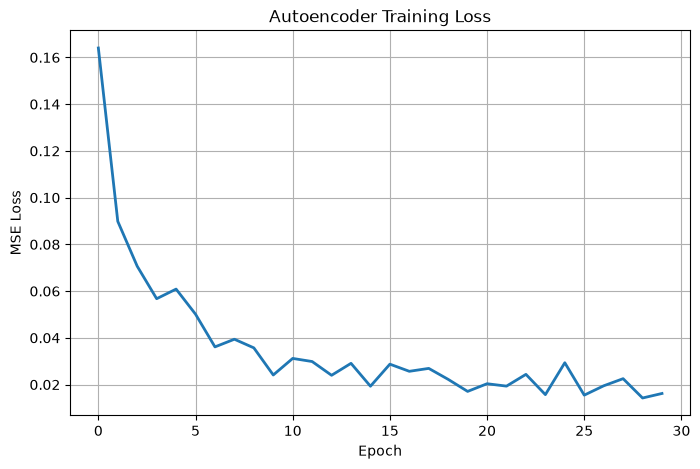

In [25]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, linewidth=2)

plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(True)

plt.show()

In [26]:
import joblib

metadata = {
    "input_dim": INPUT_DIM,
    "best_loss": best_loss,
    "epochs": EPOCHS,
    "batch_size": 512,
    "learning_rate": 0.001
}

joblib.dump(
    metadata,
    "../models/saved_models/ae_metadata.pkl"
)

print("Metadata saved successfully.")

Metadata saved successfully.
